# 📌 Extracción

In [52]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


with open("TelecomX_Data.json", 'r') as archivo:
    datos = json.load(archivo)
df = pd.DataFrame(datos)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 Transformación

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [54]:
pd.set_option('display.max_columns', None)

#Normalizar al archivo json, no al DataFrame
dfnormalizado = pd.json_normalize(datos)
dfnormalizado.columns = [col.split('.', 1)[-1] for col in dfnormalizado.columns]
dfnormalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [55]:
dfnormalizado['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [56]:
df_filtrado = dfnormalizado.loc[dfnormalizado['Churn'].isin(['Yes', ''])]
df_filtrado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
18,0022-TCJCI,Yes,Male,1,No,No,45,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Credit card (automatic),62.70,2791.5
19,0023-HGHWL,Yes,Male,1,No,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,25.10,25.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7246,9965-YOKZB,Yes,Male,1,No,No,9,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,83.85,790.15
7247,9966-VYRTZ,,Female,0,Yes,Yes,31,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.55,658.95
7260,9985-MWVIX,Yes,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15
7261,9986-BONCE,Yes,Female,0,No,No,4,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.95,85.5


In [57]:
df_churn_yes = df_filtrado[df_filtrado['Churn'] == 'Yes']
df_churn_yes.head() 


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4
18,0022-TCJCI,Yes,Male,1,No,No,45,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Credit card (automatic),62.7,2791.5
19,0023-HGHWL,Yes,Male,1,No,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,25.1,25.1


In [58]:
df_churn_nan = df_filtrado[df_filtrado['Churn'] == '']
df_churn_nan.shape

(224, 21)

# 📊 Carga y análisis
## Analisis por genero y edad

Hay 1869 clientes que han abandonado el servicio.

De los cuales la distribución por género es la siguiente:
 Mujeres: 939
 Hombres: 930

Y la cantidad de clientes mayores de 60 años que han abandonado el servicio es de: 476

Lo que representa un 25.47% del total de clientes que han abandonado el servicio.


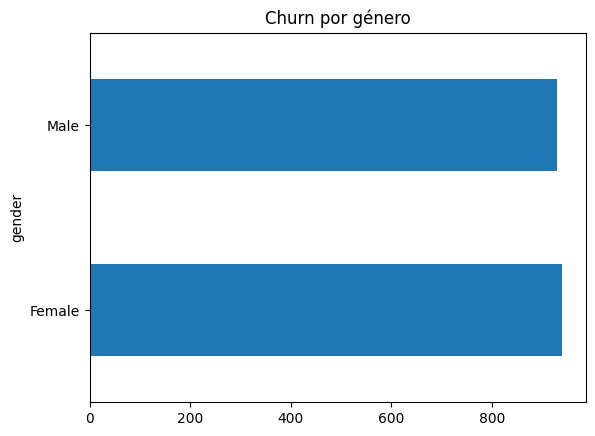

In [ ]:
df_por_genero = df_churn_yes.groupby(['gender'])['SeniorCitizen'].count()
df_por_edad = df_churn_yes.groupby(['gender'])['SeniorCitizen'].sum()
print(f'Hay {df_churn_yes.shape[0]} clientes que han abandonado el servicio.\n')
print(f'De los cuales la distribución por género es la siguiente:\n Mujeres: {df_por_genero.tolist()[0]}\n Hombres: {df_por_genero.tolist()[1]}')
print(f'\nY la cantidad de clientes mayores de 60 años que han abandonado el servicio es de: {df_por_edad.sum()}')
print(f'\nLo que representa un {df_por_edad.sum() / df_churn_yes.shape[0] * 100:.2f}% del total de clientes que han abandonado el servicio.')
df_churn_yes['gender'].value_counts().plot(kind='barh', title='Churn por género')
plt.show()


In [60]:
df_tenure = df_churn_yes[['tenure']].copy()
df_tenure = df_tenure.groupby(['tenure']).value_counts().reset_index(name='counts').sort_values(by='tenure').head(40)
df_tenure.head(6)

,tenure,counts
0,1,380
1,2,123
2,3,94
3,4,83
4,5,64
5,6,40


In [61]:
import plotly.express as px


fig = px.line(df_tenure, x='tenure', y='counts', title='Clientes que abandonaron el servicio por meses', markers=True)
fig.update_traces(line=dict(color='#FF0000', width=4),
                  marker=dict(size=8, color='white', line=dict(width=2, color='red')))

fig.update_layout(width=1200, height=600, plot_bgcolor='rgb(20,20,40)', paper_bgcolor='rgb(20,20,40)', 
                  xaxis_title='Meses', yaxis_title='Cantidad de clientes',
                  font_family='Arial', font_size=14, 
                  
                  # Título en blanco para contraste
                  title_font_color='white',
                  font_color='white',
    
                  # Ejes con colores contrastantes
                  xaxis=dict(
                  dtick=1,
                  title_font=dict(color='#FF9999'),
                  tickfont=dict(color='white'),
                  gridcolor='rgba(255,255,255,0.2)'),
                  
                
                  yaxis=dict(
                  title_font=dict(color='#99FF99'),
                  tickfont=dict(color='white'),
                  gridcolor='rgba(255,255,255,0.2)'))

fig.show()

# 📄Informe final

In [83]:
print(f'''Los primeros 7 meses se detecta una cantidad de { df_tenure["counts"].head(7).sum() } clientes que han abandonado el servicio.
\nLo que representa un { df_tenure["counts"].head(7).sum() / df_churn_yes.shape[0] * 100:.2f} % del total que han abandonado el servicio.''')

Los primeros 7 meses se detecta una cantidad de 835 clientes que han abandonado el servicio.

Lo que representa un 44.68 % del total que han abandonado el servicio.


<b><span style="font-size:25px;">Un punto clave a tener en cuenta a la hora de generar estrategias para retener a los clientes nuevos</span><b>